<a href="https://colab.research.google.com/github/khansa-020/Deep-Fake-Detection/blob/main/ML_Techniques_DeepFakeDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "i258006",\r\n  "key": "KGAT_7d264554b6ebebaed74464713e48d9c9"\r\n}'}

In [4]:
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d manjilkarki/deepfake-and-real-images
!unzip deepfake-and-real-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dataset/Validation/Real/real_5499.jpg  
  inflating: Dataset/Validation/Real/real_55.jpg  
  inflating: Dataset/Validation/Real/real_550.jpg  
  inflating: Dataset/Validation/Real/real_5500.jpg  
  inflating: Dataset/Validation/Real/real_5501.jpg  
  inflating: Dataset/Validation/Real/real_5502.jpg  
  inflating: Dataset/Validation/Real/real_5503.jpg  
  inflating: Dataset/Validation/Real/real_5504.jpg  
  inflating: Dataset/Validation/Real/real_5505.jpg  
  inflating: Dataset/Validation/Real/real_5506.jpg  
  inflating: Dataset/Validation/Real/real_5507.jpg  
  inflating: Dataset/Validation/Real/real_5508.jpg  
  inflating: Dataset/Validation/Real/real_5509.jpg  
  inflating: Dataset/Validation/Real/real_551.jpg  
  inflating: Dataset/Validation/Real/real_5510.jpg  
  inflating: Dataset/Validation/Real/real_5511.jpg  
  inflating: Dataset/Validation/Real/real_5512.jpg  
  inflating: Dataset/Validation/Real/real_5513.jpg  

In [6]:
!ls Dataset
!ls Dataset/Train

Test  Train  Validation
Fake  Real


In [18]:
import os

print("Train:", os.listdir("Dataset/Train"))
print("Validation:", os.listdir("Dataset/Validation"))
print("Test:", os.listdir("Dataset/Test"))

print("Real:", len(os.listdir("Dataset/Train/Real")))
print("Fake:", len(os.listdir("Dataset/Train/Fake")))

print("Real:", len(os.listdir("Dataset/Test/Real")))
print("Fake:", len(os.listdir("Dataset/Test/Fake")))

print("Real:", len(os.listdir("Dataset/Validation/Real")))
print("Fake:", len(os.listdir("Dataset/Validation/Fake")))

Train: ['Fake', 'Real']
Validation: ['Fake', 'Real']
Test: ['Fake', 'Real']
Real: 70001
Fake: 70001
Real: 5413
Fake: 5492
Real: 19787
Fake: 19641


In [ ]:
#PreProcessing Done

In [ ]:
# !pip install opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 24.6 MB/s eta 0:00:00


In [5]:
# ============================================================
# SVM TRAINING + SAVE EVERYTHING (ONE CELL)
# ============================================================

import os
import cv2
import joblib
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler

# ============================================================
# LOAD IMAGES
# ============================================================

def load_images(folder, limit=2000):

    images = []
    labels = []

    for label_name in ["Real", "Fake"]:

        path = os.path.join(folder, label_name)

        count = 0

        for img_name in os.listdir(path):

            if count >= limit:
                break

            img_path = os.path.join(path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            # Convert to grayscale
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Resize image
            img = cv2.resize(img, (128, 128))

            images.append(img)

            labels.append(
                0 if label_name == "Real" else 1
            )

            count += 1

    return np.array(images), np.array(labels)


# ============================================================
# LOAD DATASET
# ============================================================

print("Loading dataset...")

X_train, y_train = load_images(
    "Dataset/Train",
    limit=3000
)

X_test, y_test = load_images(
    "Dataset/Test",
    limit=600
)

X_val, y_val = load_images(
    "Dataset/Validation",
    limit=600
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)
print("Validation Shape:", X_val.shape)


# ============================================================
# PREPROCESSING
# ============================================================

# Flatten images
X_train = X_train.reshape(X_train.shape[0], -1)

X_test = X_test.reshape(X_test.shape[0], -1)

print("Flattened Shape:", X_train.shape)

# Normalize
print("Scaling features...")

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ============================================================
# TRAIN SVM
# ============================================================

print("\nTraining SVM Model...")

svm_model = SVC(
    kernel='linear',
    C=1.0,
    probability=True
)

svm_model.fit(X_train, y_train)

print("Training Complete!")


# ============================================================
# PREDICTIONS
# ============================================================

print("\nMaking Predictions...")

y_pred_svm = svm_model.predict(X_test)


# ============================================================
# EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred_svm)

report = classification_report(
    y_test,
    y_pred_svm,
    output_dict=True
)

cm = confusion_matrix(
    y_test,
    y_pred_svm
)

print("\n===================================")
print("SVM Accuracy:", accuracy)
print("===================================")

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# SAVE MODEL + RESULTS
# ============================================================

print("\nSaving files...")

# Save trained model
joblib.dump(
    svm_model,
    "svm_model.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    "svm_scaler.pkl"
)

# Save predictions
np.save(
    "svm_predictions.npy",
    y_pred_svm
)

# Save ground truth
np.save(
    "svm_true_labels.npy",
    y_test
)

# Save confusion matrix
np.save(
    "svm_confusion_matrix.npy",
    cm
)

# Save metrics
results = {
    "accuracy": accuracy,
    "classification_report": report,
    "confusion_matrix": cm
}

joblib.dump(
    results,
    "svm_results.pkl"
)

# Save experiment summary CSV
results_df = pd.DataFrame([
    {
        "Model": "SVM",
        "Kernel": "linear",
        "Image_Size": "128x128",
        "Accuracy": accuracy
    }
])

results_df.to_csv(
    "svm_experiment_results.csv",
    index=False
)

print("\n===================================")
print("Everything Saved Successfully!")
print("===================================")

print("\nSaved Files:")
print("1. svm_model.pkl")
print("2. svm_scaler.pkl")
print("3. svm_predictions.npy")
print("4. svm_true_labels.npy")
print("5. svm_confusion_matrix.npy")
print("6. svm_results.pkl")
print("7. svm_experiment_results.csv")

Loading dataset...
Train Shape: (6000, 128, 128)
Test Shape: (1200, 128, 128)
Validation Shape: (1200, 128, 128)
Flattened Shape: (6000, 16384)
Scaling features...

Training SVM Model...
Training Complete!

Making Predictions...

SVM Accuracy: 0.5983333333333334

Confusion Matrix:
[[376 224]
 [258 342]]

Saving files...

Everything Saved Successfully!

Saved Files:
1. svm_model.pkl
2. svm_scaler.pkl
3. svm_predictions.npy
4. svm_true_labels.npy
5. svm_confusion_matrix.npy
6. svm_results.pkl
7. svm_experiment_results.csv


In [20]:
# 3. SVM (raw features)------59.5
import os
import cv2
import numpy as np

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Load Images
# -------------------------------
def load_images(folder, limit=2000):
    images = []
    labels = []

    for label_name in ["Real", "Fake"]:
        path = os.path.join(folder, label_name)

        count = 0
        for img_name in os.listdir(path):
            if count >= limit:
                break

            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            # Resize image
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            img = cv2.resize(img, (128, 128))
            # img = cv2.resize(img, (68, 68))


            images.append(img)
            labels.append(0 if label_name == "Real" else 1)

            count += 1

    return np.array(images), np.array(labels)

# Load dataset
X_train, y_train = load_images("Dataset/Train", limit=3000)
X_test, y_test = load_images("Dataset/Test", limit=3000)

# -------------------------------
# Preprocessing for SVM
# -------------------------------

# Flatten images: (128,128,3) -> 49152 features
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Normalize data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# Train SVM Classifier
# -------------------------------

svm_model = SVC(
    kernel='linear',   # you can also try 'rbf'
    C=1.0
)

print("Training SVM...")
svm_model.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------

y_pred_svm = svm_model.predict(X_test)

# -------------------------------
# Evaluation
# -------------------------------

accuracy = accuracy_score(y_test, y_pred_svm)

print("\nSVM (raw)---Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Training SVM...

SVM (raw)---Accuracy: 0.6165

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.66      0.63      3000
           1       0.63      0.57      0.60      3000

    accuracy                           0.62      6000
   macro avg       0.62      0.62      0.62      6000
weighted avg       0.62      0.62      0.62      6000


Confusion Matrix:
[[1980 1020]
 [1281 1719]]


In [6]:
# 2. GLCM + SVM-------56.8
import os
import cv2
import numpy as np

from skimage.feature import graycomatrix, graycoprops

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# -----------------------------------
# Extract GLCM Features
# -----------------------------------
def extract_glcm_features(image):

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize image
    gray = cv2.resize(gray, (128, 128))

    # Create GLCM matrix
    # glcm = graycomatrix(
    #     gray,
    #     distances=[1],
    #     angles=[0],
    #     levels=256,
    #     symmetric=True,
    #     normed=True
    # )

    glcm = graycomatrix(
    gray,
    distances=[1, 2],
    angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
    levels=256,
    symmetric=True,
    normed=True
)

    # Extract texture features
    # contrast = graycoprops(glcm, 'contrast')[0, 0]
    # correlation = graycoprops(glcm, 'correlation')[0, 0]
    # energy = graycoprops(glcm, 'energy')[0, 0]
    # homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]


    contrast = graycoprops(glcm, 'contrast').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    energy = graycoprops(glcm, 'energy').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()

    return [
        contrast,
        correlation,
        energy,
        homogeneity
    ]

print("GLCM features extraction done...")

# -----------------------------------
# Load Dataset
# -----------------------------------
def load_images(folder, limit=3000):

    features = []
    labels = []

    for label_name in ["Real", "Fake"]:

        path = os.path.join(folder, label_name)

        count = 0

        for img_name in os.listdir(path):

            if count >= limit:
                break

            img_path = os.path.join(path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            # Extract GLCM features
            feature_vector = extract_glcm_features(img)

            features.append(feature_vector)

            # Real = 0, Fake = 1
            labels.append(0 if label_name == "Real" else 1)

            count += 1

    return np.array(features), np.array(labels)


# -----------------------------------
# Load Training & Testing Data
# -----------------------------------
X_train, y_train = load_images("Dataset/Train", limit=3000)

X_test, y_test = load_images("Dataset/Test", limit=3000)


# -----------------------------------
# Feature Scaling
# -----------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# -----------------------------------
# Train SVM Classifier
# -----------------------------------
svm_model = SVC(
    kernel='rbf',   # try 'linear' or 'rbf'
    C=10,
    gamma='scale'
)

print("Training SVM Model...")

svm_model.fit(X_train, y_train)


# -----------------------------------
# Prediction
# -----------------------------------
y_pred_glcm_svm = svm_model.predict(X_test)


# -----------------------------------
# Evaluation
# -----------------------------------
accuracy = accuracy_score(y_test, y_pred_glcm_svm)

print("\nGLCM + SVM ---\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_glcm_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_glcm_svm))

GLCM features extraction done...
Training SVM Model...

GLCM + SVM ---
Accuracy: 0.553

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.60      0.57      3000
           1       0.56      0.51      0.53      3000

    accuracy                           0.55      6000
   macro avg       0.55      0.55      0.55      6000
weighted avg       0.55      0.55      0.55      6000


Confusion Matrix:
[[1800 1200]
 [1482 1518]]


In [7]:
# 1. GLCM + RF
import os
import cv2
import numpy as np

from skimage.feature import graycomatrix, graycoprops

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# -----------------------------------
# Extract GLCM Features
# -----------------------------------
def extract_glcm_features(image):

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize image
    gray = cv2.resize(gray, (128, 128))

    # Create GLCM Matrix
    glcm = graycomatrix(
        gray,
        distances=[1, 2],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )

    # Extract texture features
    contrast = graycoprops(glcm, 'contrast').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    energy = graycoprops(glcm, 'energy').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()

    return [
        contrast,
        correlation,
        energy,
        homogeneity
    ]

print("GLCM done...")
# -----------------------------------
# Load Dataset
# -----------------------------------
def load_images(folder, limit=3000):

    features = []
    labels = []

    for label_name in ["Real", "Fake"]:

        path = os.path.join(folder, label_name)

        count = 0

        for img_name in os.listdir(path):

            if count >= limit:
                break

            img_path = os.path.join(path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            # Extract GLCM features
            feature_vector = extract_glcm_features(img)

            features.append(feature_vector)

            # Real = 0, Fake = 1
            labels.append(0 if label_name == "Real" else 1)

            count += 1

    return np.array(features), np.array(labels)


# -----------------------------------
# Load Train & Test Data
# -----------------------------------
X_train, y_train = load_images("Dataset/Train", limit=3000)

X_test, y_test = load_images("Dataset/Test", limit=3000)


# -----------------------------------
# Feature Scaling
# -----------------------------------
# Random Forest does not require scaling,
# but scaling can still help consistency

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# -----------------------------------
# Train Random Forest
# -----------------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

print("Training Random Forest Model...")

rf_model.fit(X_train, y_train)


# -----------------------------------
# Prediction
# -----------------------------------
y_pred_glcm_rf = rf_model.predict(X_test)


# -----------------------------------
# Evaluation
# -----------------------------------
accuracy = accuracy_score(y_test, y_pred_glcm_rf)

print("\n GLCM + Random Forest: Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_glcm_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_glcm_rf))

GLCM done...
Training Random Forest Model...

 GLCM + Random Forest: Accuracy: 0.532

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.54      0.53      3000
           1       0.53      0.53      0.53      3000

    accuracy                           0.53      6000
   macro avg       0.53      0.53      0.53      6000
weighted avg       0.53      0.53      0.53      6000


Confusion Matrix:
[[1608 1392]
 [1416 1584]]


In [8]:
# 4. HOG + Random Forest----75.58
import os
import cv2
import numpy as np

from skimage.feature import hog

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# -----------------------------------
# Extract HOG Features
# -----------------------------------
def extract_hog_features(image):

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize image
    gray = cv2.resize(gray, (128, 128))

    # Extract HOG features
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )

    return features


# -----------------------------------
# Load Dataset
# -----------------------------------
def load_images(folder, limit=3000):

    features = []
    labels = []

    for label_name in ["Real", "Fake"]:

        path = os.path.join(folder, label_name)

        count = 0

        for img_name in os.listdir(path):

            if count >= limit:
                break

            img_path = os.path.join(path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            # Extract HOG Features
            hog_features = extract_hog_features(img)

            features.append(hog_features)

            # Real = 0, Fake = 1
            labels.append(0 if label_name == "Real" else 1)

            count += 1

    return np.array(features), np.array(labels)


# -----------------------------------
# Load Train & Test Data
# -----------------------------------
X_train, y_train = load_images("Dataset/Train", limit=3000)

X_test, y_test = load_images("Dataset/Test", limit=3000)


# -----------------------------------
# Train Random Forest Classifier
# -----------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest with HOG Features...")

rf_model.fit(X_train, y_train)


# -----------------------------------
# Prediction
# -----------------------------------
y_pred_hog_rf = rf_model.predict(X_test)


# -----------------------------------
# Evaluation
# -----------------------------------
accuracy = accuracy_score(y_test, y_pred_hog_rf)

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_hog_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_hog_rf))

Training Random Forest with HOG Features...

Accuracy: 0.7078333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.70      0.71      3000
           1       0.71      0.71      0.71      3000

    accuracy                           0.71      6000
   macro avg       0.71      0.71      0.71      6000
weighted avg       0.71      0.71      0.71      6000


Confusion Matrix:
[[2108  892]
 [ 861 2139]]


In [11]:
pip install xgboost

In [ ]:
# 5. Stacked Ensemble: Random Forest + XGBoost + SVM (Meta: Logistic Regression)------------76
import os
import cv2
import numpy as np

from skimage.feature import hog

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier


# -----------------------------------
# Extract HOG Features
# -----------------------------------
def extract_hog_features(image):

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize image
    gray = cv2.resize(gray, (128, 128))

    # Extract HOG features
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )

    return features


# -----------------------------------
# Load Dataset
# -----------------------------------
def load_images(folder, limit=2000):

    features = []
    labels = []

    for label_name in ["Real", "Fake"]:

        path = os.path.join(folder, label_name)

        count = 0

        for img_name in os.listdir(path):

            if count >= limit:
                break

            img_path = os.path.join(path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            # Extract HOG Features
            hog_features = extract_hog_features(img)

            features.append(hog_features)

            # Real = 0, Fake = 1
            labels.append(0 if label_name == "Real" else 1)

            count += 1

    return np.array(features), np.array(labels)


# -----------------------------------
# Load Training & Testing Data
# -----------------------------------
X_train, y_train = load_images("Dataset/Train", limit=3000)

X_test, y_test = load_images("Dataset/Test", limit=3000)


# -----------------------------------
# Base Models
# -----------------------------------
rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss'
)

svm_model = SVC(
    kernel='rbf',
    probability=True
)


# -----------------------------------
# Stacking Ensemble
# -----------------------------------
stack_model = StackingClassifier(

    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('svm', svm_model)
    ],

    final_estimator=LogisticRegression(),

    cv=5,

    n_jobs=-1
)


# -----------------------------------
# Train Model
# -----------------------------------
print("Training Stacked Ensemble Model...")

stack_model.fit(X_train, y_train)


# -----------------------------------
# Prediction
# -----------------------------------
y_pred_stack = stack_model.predict(X_test)


# -----------------------------------
# Evaluation
# -----------------------------------
accuracy = accuracy_score(y_test, y_pred_stack)

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_stack))

In [12]:
# 6. HOG + XGBoost + SVM (Voting Ensemble)-----84.6
import os
import cv2
import numpy as np

from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier


# -----------------------------------
# Extract HOG Features
# -----------------------------------
def extract_hog_features(image):

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize image
    gray = cv2.resize(gray, (128, 128))

    # Extract HOG features
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )

    return features


# -----------------------------------
# Load Dataset
# -----------------------------------
def load_images(folder, limit=2000):

    features = []
    labels = []

    for label_name in ["Real", "Fake"]:

        path = os.path.join(folder, label_name)

        count = 0

        for img_name in os.listdir(path):

            if count >= limit:
                break

            img_path = os.path.join(path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            # Extract HOG Features
            hog_features = extract_hog_features(img)

            features.append(hog_features)

            # Real = 0, Fake = 1
            labels.append(0 if label_name == "Real" else 1)

            count += 1

    return np.array(features), np.array(labels)


# -----------------------------------
# Load Train & Test Data
# -----------------------------------
X_train, y_train = load_images("Dataset/Train", limit=3000)

X_test, y_test = load_images("Dataset/Test", limit=3000)


# -----------------------------------
# Feature Scaling
# -----------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# -----------------------------------
# Individual Models
# -----------------------------------

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    # use_label_encoder=False,
    eval_metric='logloss'
)

# SVM
svm_model = SVC(
    kernel='rbf',
    probability=True
)


# -----------------------------------
# Voting Ensemble
# -----------------------------------
voting_model = VotingClassifier(

    estimators=[
        ('xgb', xgb_model),
        ('svm', svm_model)
    ],

    voting='soft'   # soft voting uses probabilities
)


# -----------------------------------
# Train Model
# -----------------------------------
print("Training HOG + XGBoost + SVM Voting Ensemble...")

voting_model.fit(X_train, y_train)


# -----------------------------------
# Prediction
# -----------------------------------
y_pred_voting = voting_model.predict(X_test)


# -----------------------------------
# Evaluation
# -----------------------------------
accuracy = accuracy_score(y_test, y_pred_voting)

print("\nHOG + XGBoost + SVM (Voting Ensemble)---Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_voting))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_voting))

Training HOG + XGBoost + SVM Voting Ensemble...

HOG + XGBoost + SVM (Voting Ensemble)---Accuracy: 0.749

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.74      0.75      3000
           1       0.75      0.76      0.75      3000

    accuracy                           0.75      6000
   macro avg       0.75      0.75      0.75      6000
weighted avg       0.75      0.75      0.75      6000


Confusion Matrix:
[[2225  775]
 [ 731 2269]]


In [ ]:
# 7.


In [13]:
# 7. Random Forest + XGBoost - data preprocessing, HOG , PCA, and hyperparameter tuning-----79.8
import os
import cv2
import numpy as np

from skimage.feature import hog

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ---------------------------------------------------
# HOG Feature Extraction
# ---------------------------------------------------
def extract_hog_features(image):

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize image
    gray = cv2.resize(gray, (128, 128))

    # HOG Features
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )

    return features


# ---------------------------------------------------
# Load Dataset
# ---------------------------------------------------
def load_images(folder, limit=3000):

    features = []
    labels = []

    for label_name in ["Real", "Fake"]:

        path = os.path.join(folder, label_name)

        count = 0

        for img_name in os.listdir(path):

            if count >= limit:
                break

            img_path = os.path.join(path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            # Extract HOG Features
            hog_features = extract_hog_features(img)

            features.append(hog_features)

            # Real = 0 | Fake = 1
            labels.append(0 if label_name == "Real" else 1)

            count += 1

    return np.array(features), np.array(labels)


# ---------------------------------------------------
# Load Train/Test Data
# ---------------------------------------------------
print("Loading dataset...")

X_train, y_train = load_images("Dataset/Train", limit=3000)

X_test, y_test = load_images("Dataset/Test", limit=3000)


# ---------------------------------------------------
# Feature Scaling
# ---------------------------------------------------
print("Scaling features...")

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ---------------------------------------------------
# PCA Dimensionality Reduction
# ---------------------------------------------------
print("Applying PCA...")

pca = PCA(n_components=0.95)

X_train = pca.fit_transform(X_train)

X_test = pca.transform(X_test)

print("Reduced Feature Size:", X_train.shape[1])


# ---------------------------------------------------
# Random Forest Hyperparameter Tuning
# ---------------------------------------------------
print("Tuning Random Forest...")

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best RF Params:", rf_grid.best_params_)


# ---------------------------------------------------
# XGBoost Hyperparameter Tuning
# ---------------------------------------------------
print("Tuning XGBoost...")

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    xgb_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

print("Best XGB Params:", xgb_grid.best_params_)


# ---------------------------------------------------
# Voting Ensemble
# ---------------------------------------------------
ensemble_model = VotingClassifier(

    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],

    voting='soft'
)


# ---------------------------------------------------
# Train Ensemble
# ---------------------------------------------------
print("Training HOG + PCA + hyperparameter + RF + XGBoost  Model...")

ensemble_model.fit(X_train, y_train)


# ---------------------------------------------------
# Prediction
# ---------------------------------------------------
y_pred_tuning = ensemble_model.predict(X_test)


# ---------------------------------------------------
# Evaluation
# ---------------------------------------------------
accuracy = accuracy_score(y_test, y_pred_tuning)

print("\nFinal Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuning))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuning))

Loading dataset...
Scaling features...
Applying PCA...
Reduced Feature Size: 1760
Tuning Random Forest...
Best RF Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:16:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Training HOG + PCA + hyperparameter + RF + XGBoost  Model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:21:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Final Accuracy: 0.7091666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.74      0.72      3000
           1       0.72      0.68      0.70      3000

    accuracy                           0.71      6000
   macro avg       0.71      0.71      0.71      6000
weighted avg       0.71      0.71      0.71      6000


Confusion Matrix:
[[2227  773]
 [ 972 2028]]


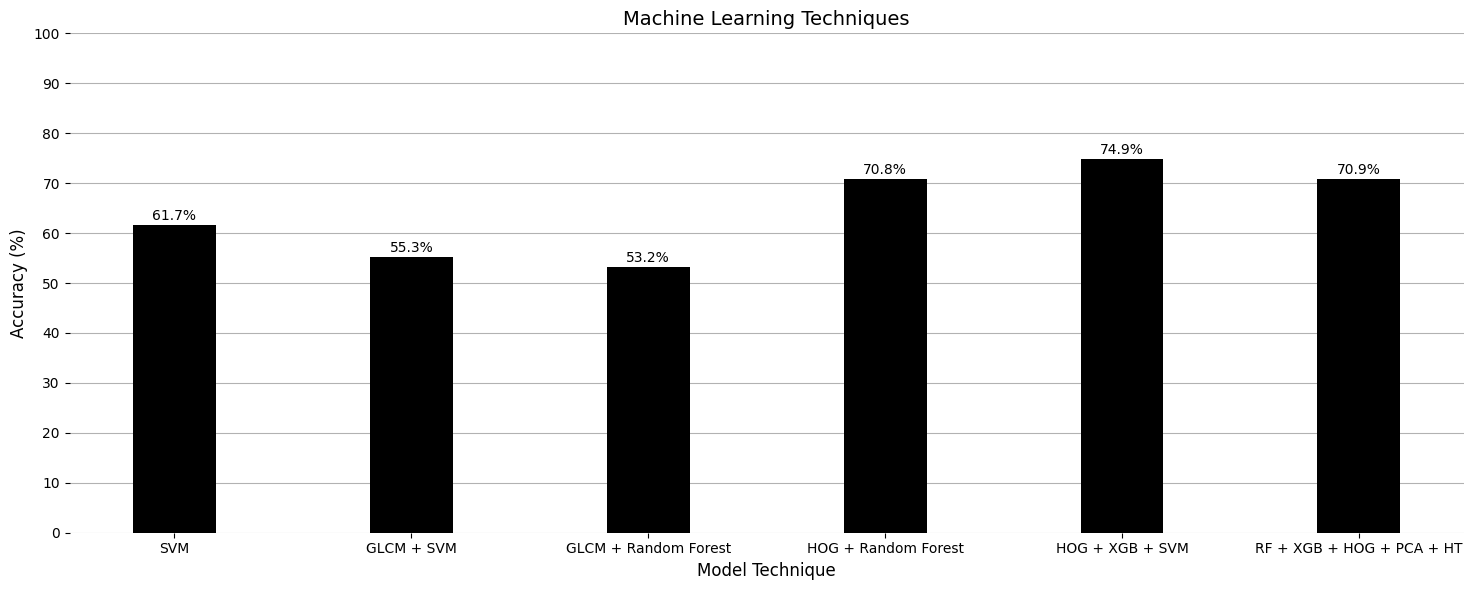

In [22]:
# MACHINE LEARNING TECHNIQUES ACCURACY COMPARISION GRAPH---
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# -----------------------------------
# Calculate Accuracies
# -----------------------------------

svm_accuracy = accuracy_score(y_test, y_pred_svm) * 100
glcm_svm_accuracy = accuracy_score(y_test, y_pred_glcm_svm) * 100
glcm_rf_accuracy = accuracy_score(y_test, y_pred_glcm_rf) * 100
accuracy_hog_rf = accuracy_score(y_test, y_pred_hog_rf) * 100
# stack_accuracy = accuracy_score(y_test, y_pred_stack) * 100
voting_accuracy = accuracy_score(y_test, y_pred_voting) * 100
ensemble_accuracy = accuracy_score(y_test, y_pred_tuning) * 100


# -----------------------------------
# Data
# -----------------------------------

models = [
    "SVM",
    "GLCM + SVM",
    "GLCM + Random Forest",
    "HOG + Random Forest",
    # "Stacked Ensemble",
    "HOG + XGB + SVM",
    "RF + XGB + HOG + PCA + HT"
]

accuracies = [
    svm_accuracy,
    glcm_svm_accuracy,
    glcm_rf_accuracy,
    accuracy_hog_rf,
    # stack_accuracy,
    voting_accuracy,
    ensemble_accuracy
]

# -----------------------------------
# Plot
# -----------------------------------

plt.figure(figsize=(15, 6), facecolor='white')

ax = plt.gca()
ax.set_facecolor('white')

# Bars
bars = plt.bar(
    models,
    accuracies,
    color='black',
    width=0.35
)

# Gridlines
plt.grid(axis='y', color='black', alpha=0.3)

# Remove borders
for spine in ax.spines.values():
    spine.set_visible(False)

# Labels
plt.xlabel("Model Technique", fontsize=12, color='black')
plt.ylabel("Accuracy (%)", fontsize=12, color='black')
plt.title("Machine Learning Techniques", fontsize=14, color='black')

# -----------------------------------
# Y-axis from 0 to 100 with 10 gap
# -----------------------------------

plt.ylim(0, 100)
plt.yticks(range(0, 101, 10), color='black')

# X-axis tick color
plt.xticks(color='black')

# Accuracy labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

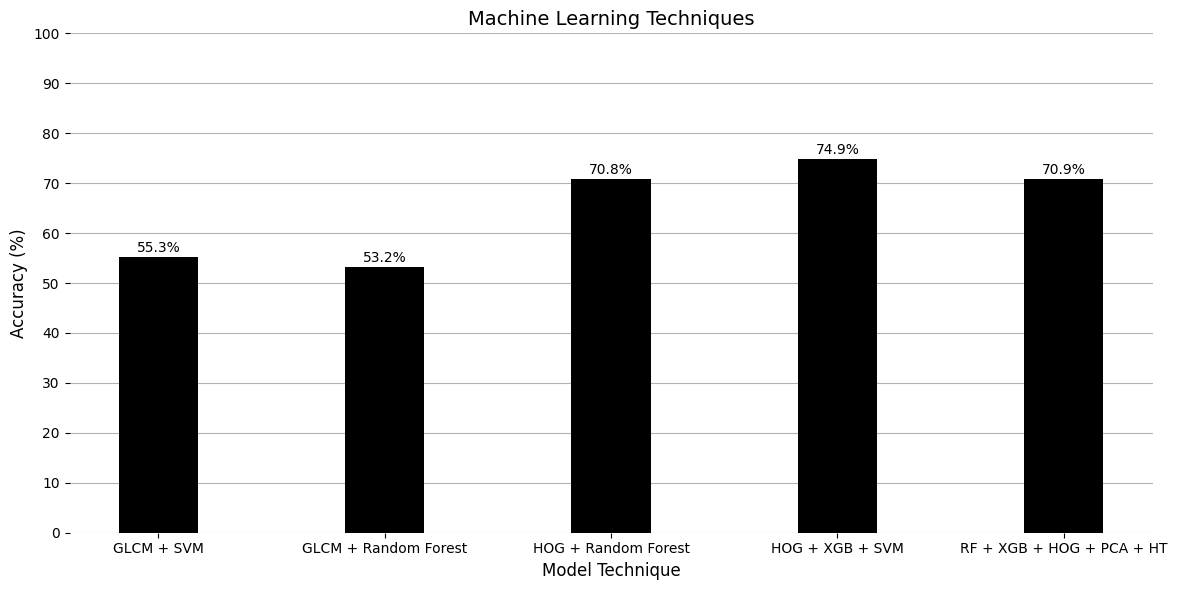

In [15]:
# MACHINE LEARNING TECHNIQUES ACCURACY COMPARISION GRAPH---
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# -----------------------------------
# Calculate Accuracies
# -----------------------------------

# svm_accuracy = accuracy_score(y_test, y_pred_svm) * 100
glcm_svm_accuracy = accuracy_score(y_test, y_pred_glcm_svm) * 100
glcm_rf_accuracy = accuracy_score(y_test, y_pred_glcm_rf) * 100
accuracy_hog_rf = accuracy_score(y_test, y_pred_hog_rf) * 100
# stack_accuracy = accuracy_score(y_test, y_pred_stack) * 100
voting_accuracy = accuracy_score(y_test, y_pred_voting) * 100
ensemble_accuracy = accuracy_score(y_test, y_pred_tuning) * 100


# -----------------------------------
# Data
# -----------------------------------

models = [
    # "SVM",
    "GLCM + SVM",
    "GLCM + Random Forest",
    "HOG + Random Forest",
    # "Stacked Ensemble",
    "HOG + XGB + SVM",
    "RF + XGB + HOG + PCA + HT"
]

accuracies = [
    # svm_accuracy,
    glcm_svm_accuracy,
    glcm_rf_accuracy,
    accuracy_hog_rf,
    # stack_accuracy,
    voting_accuracy,
    ensemble_accuracy
]

# -----------------------------------
# Plot
# -----------------------------------

plt.figure(figsize=(12, 6), facecolor='white')

ax = plt.gca()
ax.set_facecolor('white')

# Bars
bars = plt.bar(
    models,
    accuracies,
    color='black',
    width=0.35
)

# Gridlines
plt.grid(axis='y', color='black', alpha=0.3)

# Remove borders
for spine in ax.spines.values():
    spine.set_visible(False)

# Labels
plt.xlabel("Model Technique", fontsize=12, color='black')
plt.ylabel("Accuracy (%)", fontsize=12, color='black')
plt.title("Machine Learning Techniques", fontsize=14, color='black')

# -----------------------------------
# Y-axis from 0 to 100 with 10 gap
# -----------------------------------

plt.ylim(0, 100)
plt.yticks(range(0, 101, 10), color='black')

# X-axis tick color
plt.xticks(color='black')

# Accuracy labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

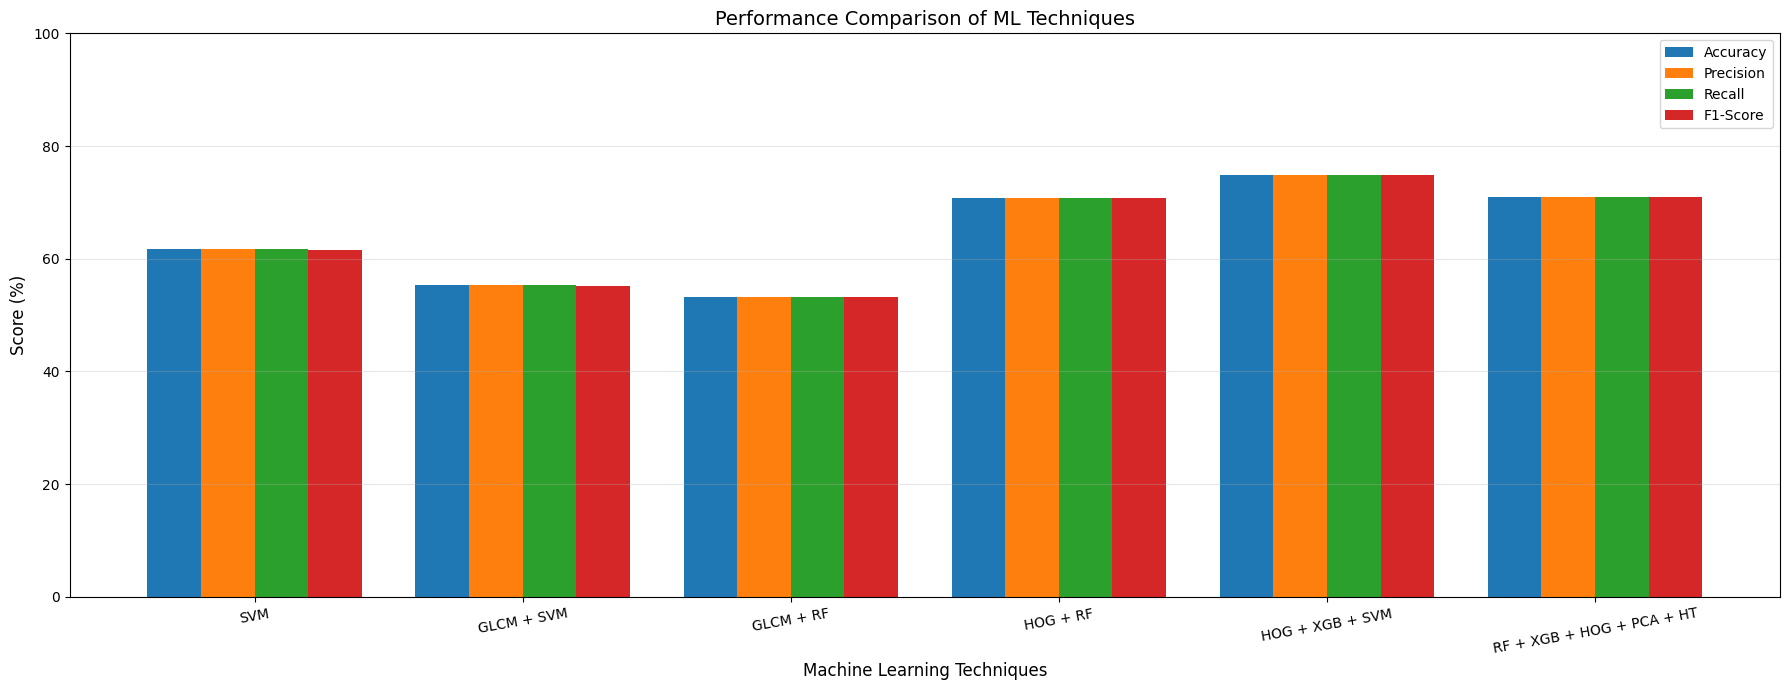

In [25]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# -----------------------------------
# Store Predictions
# -----------------------------------

model_results = {
    "SVM": y_pred_svm,
    "GLCM + SVM": y_pred_glcm_svm,
    "GLCM + RF": y_pred_glcm_rf,
    "HOG + RF": y_pred_hog_rf,
    "HOG + XGB + SVM": y_pred_voting,
    "RF + XGB + HOG + PCA + HT": y_pred_tuning
}

# -----------------------------------
# Calculate Metrics
# -----------------------------------

models = []
accuracies = []
precisions = []
recalls = []
f1_scores = []

for model_name, predictions in model_results.items():

    models.append(model_name)

    accuracies.append(
        accuracy_score(y_test, predictions) * 100
    )

    precisions.append(
        precision_score(y_test, predictions, average='weighted') * 100
    )

    recalls.append(
        recall_score(y_test, predictions, average='weighted') * 100
    )

    f1_scores.append(
        f1_score(y_test, predictions, average='weighted') * 100
    )

# -----------------------------------
# Plot
# -----------------------------------

x = np.arange(len(models))

width = 0.2

plt.figure(figsize=(18, 7))

# Bars
plt.bar(x - 1.5*width, accuracies, width, label='Accuracy')
plt.bar(x - 0.5*width, precisions, width, label='Precision')
plt.bar(x + 0.5*width, recalls, width, label='Recall')
plt.bar(x + 1.5*width, f1_scores, width, label='F1-Score')

# Labels
plt.xlabel("Machine Learning Techniques", fontsize=12)
plt.ylabel("Score (%)", fontsize=12)

plt.title("Performance Comparison of ML Techniques", fontsize=14)

# X ticks
plt.xticks(x, models, rotation=10)

# Y-axis
plt.ylim(0, 100)

# Grid
plt.grid(axis='y', alpha=0.3)

# Legend
plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# 1. GLCM + RandomForest
# 2. SVM + GLCM Accuracy
# 3. SVM classifier
# 4. Random Forest Classifier with HOG Features
# 5. Stacked Ensemble: Random Forest + XGBoost + SVM (Meta: Logistic Regression)
# 6. HOG + XGBoost + SVM (Voting Ensemble)
# 7. Forest + XGBoost with proper data preprocessing, HOG feature extraction, PCA, and hyperparameter tuning